## analysing the changes in upwelling

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import pandas as pd


In [4]:
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


In [5]:
import cmocean
from scipy import stats

In [6]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 0.8
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [7]:
def plot_decorator():
    ax = plt.gca()
    
    # Minor ticks
    # ax.minorticks_on()
    # plt.tick_params(which='minor', axis='x', bottom=False)
    
    # Grid (light, behind data)
    ax.grid(color='gray', lw=0.4, alpha=0.1)
    
    # Remove top/right spines (Nature style)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tight layout
    # plt.tight_layout()

In [8]:
from matplotlib.colors import BoundaryNorm as BM
# from matplotlib.colors import LogNorm as LM
import matplotlib.patches as mpatches

In [141]:
def plot_background(ax, draw_labels=False):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=draw_labels,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax



def add_qk_bbox(ax, qk, q, patch_zorder):
    # --- Add a box around both arrow and label ---
    # Choose size & position in Axes fraction coordinates
    box_x, box_y = 1.03, 1.07   # lower-left corner of box
    box_w, box_h = 0.14, 0.05    # width & height of box

    rect = mpatches.FancyBboxPatch(
        (box_x, box_y), box_w, box_h,
        transform=ax.transAxes,
        boxstyle="square,pad=0.25",
        facecolor='white', edgecolor='black', alpha=1.0,
        zorder=patch_zorder, clip_on=True  # below text & arrow
    )
    ax.add_patch(rect)

    # Raise the quiverkey elements above the box
    qk.text.set_zorder(4)
    q.set_zorder(2)


def plot_maps(x, y, z, titles, labels, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
            nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
            cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=False, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        if draw_labels:
            plot_background(ax, draw_labels)
        else:
            plot_background(ax)
        if auto_aspect:
            ax.set_aspect('auto')
        else:
            continue
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        if draw_winds:
            # step = max(1, x.shape[0] // 2)
            step = 6
            # q = axlist[i].quiver(x[::step, ::step], y[::step, ::step], u_wnd[i][::step, ::step], v_wnd[i][::step, ::step], scale=wind_scale, color='k', pivot='middle', transform=ccrs.PlateCarree())
            q = axlist[i].quiver(x[::step, ::step], y[::step, ::step], u_wnd[i][::step, ::step], v_wnd[i][::step, ::step], scale_units='xy', scale=wind_scale, width=0.003, headwidth=3, headlength=4, headaxislength=3, color='k', pivot='middle', transform=ccrs.PlateCarree())
            if i == 0:
                qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
                add_qk_bbox(axlist[i], qk, q, patch_zorder=4)
            # qk.text.set_bbox(dict(facecolor='white', edgecolor='k', boxstyle='square,pad=0.3'))

        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.9)
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
                axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':14})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        fig.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])



def plot_single_map(x, y, z, title, label, cmap, levels, pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
                figsize=(12,4), land_mask_list = False, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160), 
                cbar_kwargs=dict(orientation='vertical', label='Precip', aspect=40, shrink=0.7, pad=0.05), draw_labels=False, draw_colorbar=True, auto_aspect=False):

    plt.figure(figsize=figsize)
    ax = plt.axes(projection=proj)
    if draw_labels:
        plot_background(ax, draw_labels)
    else:
        plot_background(ax)
    if auto_aspect:
        ax.set_aspect('auto')
    
    cf=ax.contourf(x, y, z, cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
    if draw_winds:
        wind_separation = 6
        q = ax.quiver(x[::wind_separation, ::wind_separation], y[::wind_separation, ::wind_separation], u_wnd.to_numpy()[::wind_separation, ::wind_separation], v_wnd.to_numpy()[::wind_separation, ::wind_separation], scale=wind_scale, \
        color='k', transform=ccrs.PlateCarree())
        qk = ax.quiverkey(q, X=0.85, Y=0.9, U=1.0, label='1 m/s', labelpos='E', coordinates='axes')
        # qk.text.set_bbox(dict(facecolor='white', edgecolor='k'))#, boxstyle='round,pad=0.3'))

        plt.tight_layout()
        plt.show()
    if draw_contour:
        ax.contour(x, y, contour_data, cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0), alpha=0.9)
    if land_mask_list:
        ax.add_feature(cfeature.LAND, color = 'k', zorder=1)
    if pval != []:
        if hatch_type == 'insig':
            pval_plot = np.ma.masked_less_equal(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
        elif hatch_type == 'sig':
            pval_plot = np.ma.masked_greater(pval, 0.05)
            ax.pcolor(x, y, pval_plot, alpha = 0., hatch='...', transform = ccrs.PlateCarree(central_longitude=0))
    ax.set_title(title, fontdict={'fontsize':14})
    ax.text(0.1, 1.05, label, size=16, fontweight='bold', transform=ax.transAxes)
    if add_patch:
        ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                        facecolor='none', edgecolor='k',
                                        transform=ccrs.PlateCarree()))
    
    if add_patch_extra:
        ax.add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
        ax.add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                    facecolor='none', edgecolor='k', lw=1.5,
                                                    transform=ccrs.PlateCarree()))
                    
    if draw_colorbar:
        norm = BM(levels, 256, extend='both')
        plt.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap=cmap), ax = ax, \
                    orientation = cbar_kwargs['orientation'], shrink=cbar_kwargs['shrink'], aspect = cbar_kwargs['aspect'], pad = cbar_kwargs['pad'], label = cbar_kwargs['label'], ticks=levels[::2])
    return ax

In [10]:
from functions import preproc_funcs as funcs

In [11]:
from functions import xr_lowess

### import data

In [12]:
import glob

In [13]:
def open_da_zarr(files):
    datasets = [xr.open_zarr(f, use_cftime=True) for f in files]
    combined = xr.concat([ds['wo'] for ds in datasets], dim='model')
    return combined.load()

In [14]:
from dask.diagnostics import ProgressBar

In [27]:
files_trans = glob.glob('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens_40_member/wo/*.zarr')
with ProgressBar():
    wo_trans_orig = open_da_zarr(files_trans)

/scratch/gb02/as8561/tmp/ipykernel_683292/3082890974.py:2: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  datasets = [xr.open_zarr(f, use_cftime=True) for f in files]
/scratch/gb02/as8561/tmp/ipykernel_683292/3082890974.py:2: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  datasets = [xr.open_zarr(f, use_cftime=True) for f in files]
/scratch/gb02/as8561/tmp/ipykernel_683292/3082890974.py:2: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetime

[                                        ] | 0% Completed | 2.02 ms

/scratch/gb02/as8561/tmp/ipykernel_683292/3082890974.py:2: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  datasets = [xr.open_zarr(f, use_cftime=True) for f in files]
/scratch/gb02/as8561/tmp/ipykernel_683292/3082890974.py:2: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  datasets = [xr.open_zarr(f, use_cftime=True) for f in files]
/scratch/gb02/as8561/tmp/ipykernel_683292/3082890974.py:2: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetime

[########################################] | 100% Completed | 115.93 ms
[########################################] | 100% Completed | 115.18 ms
[########################################] | 100% Completed | 117.83 ms
[########################################] | 100% Completed | 112.77 ms
[########################################] | 100% Completed | 114.61 ms
[########################################] | 100% Completed | 112.54 ms
[########################################] | 100% Completed | 110.48 ms
[########################################] | 100% Completed | 107.63 ms
[########################################] | 100% Completed | 114.12 ms
[########################################] | 100% Completed | 113.14 ms
[########################################] | 100% Completed | 757.90 ms
[########################################] | 100% Completed | 111.20 ms
[########################################] | 100% Completed | 111.71 ms
[########################################] | 100% Completed | 11

In [28]:
# thetao_tropics_trans = funcs.calc_anom(thetao_tropics_trans_orig, thetao_tropics_trans_orig.sel(model = 10).sel(time = slice('1960', '1990')))

In [29]:
with ProgressBar():
    wo_stable2030 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/wo/access_stable_2030*.nc', concat_dim='time', combine='nested', use_cftime=True).load()
    print('done')
    wo_stable2045 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/wo/access_stable_2045*.nc', concat_dim='time', combine='nested', use_cftime=True).load()
    print('done')
    wo_stable2060 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/wo/access_stable_2060*.nc', concat_dim='time', combine='nested', use_cftime=True).load()
    print('done')


[##########################              ] | 66% Completed | 118.09 ms

/scratch/gb02/as8561/tmp/ipykernel_683292/3214645255.py:2: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  wo_stable2030 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/wo/access_stable_2030*.nc', concat_dim='time', combine='nested', use_cftime=True).load()


[########################################] | 100% Completed | 521.71 ms


done
[##########################              ] | 66% Completed | 117.77 ms

/scratch/gb02/as8561/tmp/ipykernel_683292/3214645255.py:4: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  wo_stable2045 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/wo/access_stable_2045*.nc', concat_dim='time', combine='nested', use_cftime=True).load()


[########################################] | 100% Completed | 521.39 ms
done
[#############                           ] | 33% Completed | 119.49 ms

/scratch/gb02/as8561/tmp/ipykernel_683292/3214645255.py:6: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  wo_stable2060 = xr.open_mfdataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/wo/access_stable_2060*.nc', concat_dim='time', combine='nested', use_cftime=True).load()


[########################################] | 100% Completed | 522.96 ms
done


In [30]:
import xesmf as xe

In [31]:
ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
ds_out

<xarray.Dataset> Size: 9kB
Dimensions:             (lon: 240, bound: 2, lat: 120)
Coordinates:
  * lon                 (lon) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25
    latitude_longitude  float64 8B nan
Dimensions without coordinates: bound
Data variables:
    lon_bounds          (lon, bound) float64 4kB -0.75 0.75 0.75 ... 357.8 359.2
    lat_bounds          (lat, bound) float64 2kB -90.0 -88.5 -88.5 ... 88.5 90.0

In [33]:
regridder = xe.Regridder(wo_trans_orig, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)

In [34]:
wo_trans_orig = regridder(wo_trans_orig)
wo_stable2030 = regridder(wo_stable2030)
wo_stable2045 = regridder(wo_stable2045)
wo_stable2060 = regridder(wo_stable2060)

In [35]:
wo_trans_orig

<xarray.DataArray (model: 40, time: 252, lat: 120, lon: 240)> Size: 1GB
array([[[[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [ 9.64644045e-08,  8.03598539e-08,  6.52638406e-08, ...,
           1.55913057e-07,  1.34740986e-07,  1.13165036e-07],
         [-1.11565676e-07, -1.12963733e-07, -1.13808277e-07, ...,
          -1.06218948e-07, -1.07981649e-07, -1.09737393e-07],
         [ 4.32721947e-08,  4.18990211e-08,  4.06094713e-08, ...,
           4.56335520e-08,  4.50987159e-08,  4.47296706e-08]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
...
           3.60310537e-07,  3.69633000e-07,  3.77295947e-07],
         [ 9.37159683e-08,  8.22055100e-08,  7.06890333e-08, ...,
           1.06223311e-07,  1.05456841e-07,  1.04775538e-07],
         [-4.38616581e-07, -4.48067595e-07, -4.57775599e-07, ...,
          -4.26291962e-07, -4.27831111e-07, -4.29414030e-07]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [ 1.01208730e-06,  1.02216018e-06,  1.01359456e-06, ...,
           1.02936372e-06,  1.01577484e-06,  1.00266118e-06],
         [ 7.34932087e-07,  7.31781824e-07,  7.29607791e-07, ...,
           7.26404721e-07,  7.32204001e-07,  7.38553524e-07],
         [ 6.04587058e-07,  6.00856652e-07,  5.97314056e-07, ...,
           6.01088118e-07,  6.04649472e-07,  6.08481571e-07]]]],
      dtype=float32)
Coordinates:
  * time                (time) object 2kB 1849-06-01 00:00:00 ... 2100-06-01 ...
  * lon                 (lon) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
    latitude_longitude  float64 8B nan
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25
Dimensions without coordinates: model
Attributes:
    regrid_method:  bilinear

In [94]:
wo_trans = funcs.calc_anom(wo_trans_orig, wo_trans_orig.sel(model = 10, time = slice('1850', '1900')))

In [106]:
wo_stable2030_anom = funcs.calc_anom_annual(wo_stable2030, wo_trans_orig.sel(model = 10, time = slice('1850', '1900')))
wo_stable2045_anom = funcs.calc_anom_annual(wo_stable2045, wo_trans_orig.sel(model = 10, time = slice('1850', '1900')))
wo_stable2060_anom = funcs.calc_anom_annual(wo_stable2060, wo_trans_orig.sel(model = 10, time = slice('1850', '1900')))

In [125]:
# plot_list = [
#     (wo_trans.wo/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2045', '2075')).mean(('model', 'time')),
#     (wo_trans.wo/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2030', '2060')).mean(('model', 'time')),
#     (wo_trans.wo/100).sel(lat = slice(-30, 30), lon = slice(100, 300)).sel(time = slice('2015', '2045')).mean(('model', 'time')),
# ]

plot_list = [
    (wo_trans*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('2045', '2075')).mean(('model', 'time')),
    (wo_trans*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('2030', '2060')).mean(('model', 'time')),
    (wo_trans*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('2015', '2045')).mean(('model', 'time')),
]

In [126]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

In [127]:
contour_data = [
    (wo_trans_orig*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('1850', '1900')).mean(('model', 'time')),
    (wo_trans_orig*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('1850', '1900')).mean(('model', 'time')),
    (wo_trans_orig*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('1850', '1900')).mean(('model', 'time')),
]

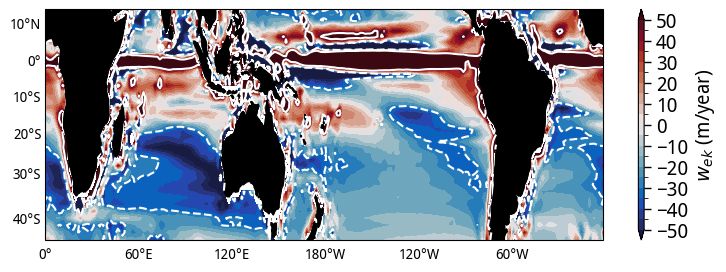

In [146]:
zz = (wo_trans_orig*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('1850', '1900')).mean(('model', 'time'))

ax = plot_single_map(xx, yy, zz, '', '', cmap=cmocean.cm.balance, levels=np.linspace(-50, 50, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', 
                figsize=(9,3), land_mask_list = True, add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.Mercator(central_longitude=180),
                cbar_kwargs=dict(orientation='vertical', label='$w_{ek}$ (m/year)', aspect=40, shrink=1.0, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=True)
ax.contour(xx, yy, zz, levels=[-30, 50], colors='white', transform=ccrs.PlateCarree())

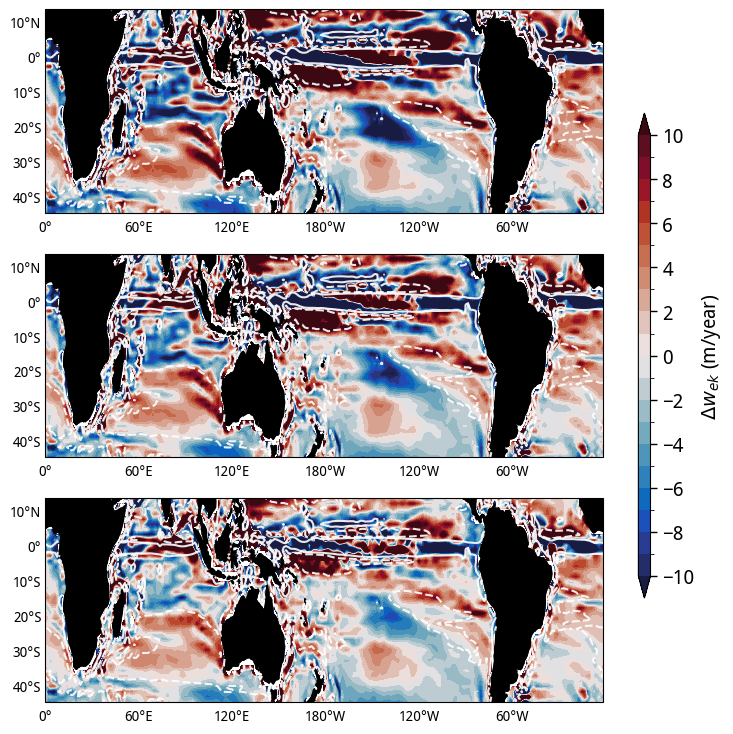

In [138]:
plot_maps(xx, yy, plot_list, ['']*3, ['']*3, cmap=cmocean.cm.balance, levels = np.linspace(-10, 10, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=0.09, draw_contour=True, contour_data=contour_data, contour_levels=[-30, 50], contour_colors='white', 
            nrows=3, ncols=1, figsize=(9,9), land_mask_list = np.arange(0, 3, 1), add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label='$\Delta w_{ek}$ (m/year)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=True)


In [102]:
def additional_sampling_stabilisation(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer)).mean('time')
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


def additional_sampling_stabilisation_nomeans(da, initiator=100, spacer=30):
    i = initiator
    da_list = []
    while i <= 1000 - spacer:
        sample_da = da.isel(time = slice(i,i+spacer))
        da_list.append(sample_da)
        i += spacer
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, (1000 - initiator)/spacer, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


In [139]:
stable_plot_list = [
    additional_sampling_stabilisation((wo_stable2060_anom.wo*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('2060', '3060'))).mean(('model')),
    additional_sampling_stabilisation((wo_stable2045_anom.wo*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('2045', '3045'))).mean(('model')),
    additional_sampling_stabilisation((wo_stable2030_anom.wo*3.154e7).sel(lat = slice(-45, 15)).sel(time = slice('2030', '3030'))).mean(('model')),
]

Done
Done
Done


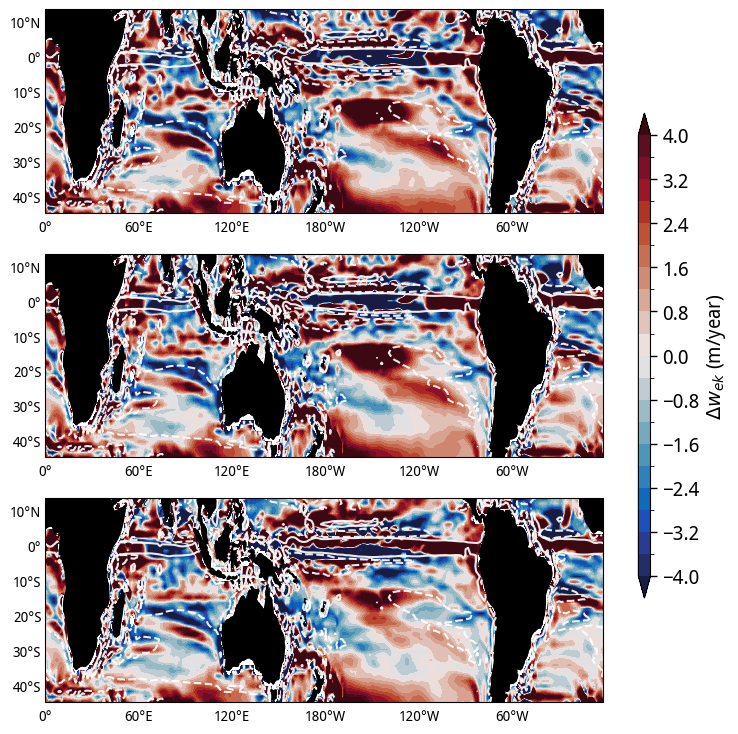

In [140]:
plot_maps(xx, yy, np.array(stable_plot_list) - np.array(plot_list), ['']*3, ['']*3, cmap=cmocean.cm.balance, levels = np.linspace(-4, 4, 21), pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=0.09, draw_contour=True, contour_data=contour_data, contour_levels=[-30, 50], contour_colors='white', 
            nrows=3, ncols=1, figsize=(9,9), land_mask_list = np.arange(0, 3, 1), add_patch=False, add_patch_extra=False, hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=180), 
            cbar_kwargs=dict(orientation='vertical', label='$\Delta w_{ek}$ (m/year)', aspect=40, shrink=0.7, pad=0.05), draw_labels=True, draw_colorbar=True, auto_aspect=True)
